## 2. Segmentation

1. Plot avaiable data 
2. Otsus Threshold 
3. Multi-Otsu Threshold
4. Sauvola Threshold
5. Compare Methods
6. Apply Sauvola on 3D image


In [1]:
# load packages
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import stackview
from skimage import io, img_as_float, img_as_ubyte
from skimage.filters import threshold_otsu, threshold_multiotsu
from skimage.morphology import remove_small_objects
from skimage.exposure import rescale_intensity

BASE_DIR = Path.cwd().parent
PLANE = 160             # sample plane for all 2D threshold demos / comparison (matches the manual annotation)
VMAX_PERCENTILE = 99.5  # display-only contrast cap for grayscale intensity previews

def disp_vmax(img):
    """Percentile-based vmax for grayscale intensity displays (mirrors the 1_2 notebook)."""
    return np.percentile(img, VMAX_PERCENTILE)

sys.path.append(str(BASE_DIR / 'src'))
# project modules
from quantification import count_connexin_plaques_within_plaque, count_connexin_plaques
from threshold import adapted_sauvola_threshold, savola_3D_image

### Changes made in Nuclei images 

- crop slices to include 60-500 (includes both slices 60 and 500 = 441 slices)
- crop image in the XY plane starting from X coordinate 26 and ending in 1002 (=976 pixels in X)
- keep Y as it is

nuclei_mask = nuclei_mask[60:501, :, 26:1002] 

### Changes made to Connexin images

- cnx_img = cnx_img[:,15:, 3:]

### That they match: 
cnx_img needs to be cut further like this: cnx_img = cnx_img[60:501, :, 29:1004]
nuclei mask need to be cut like this: nuclei_mask = nuclei_mask[:, 15:, :]

In [2]:
# load image and nuclei mask (the nuclei stack was cropped in z BEFORE export, so it is already in the connexin frame)
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')
preprocessed_image= preprocessed_image[60:501, :, 23:999]  
preprocessed_image_bg = io.imread(BASE_DIR / 'data/preprocessed/background_removed_img.tiff')
preprocessed_image_bg = preprocessed_image_bg[60:501, :, 23:999]
nuclei_mask_raw = io.imread(BASE_DIR / 'data/raw/nuclei_dataset/nuclei_1_raw_Object Identities_test-exported_data_Input.tiff')
nuclei_mask = nuclei_mask_raw[:, 15:, :]  # file was already cropped in z (441 planes) and x (976 px) to the connexin frame before export; here we only trim the top 15 y-pixels

In [3]:
print(preprocessed_image.shape)
print(preprocessed_image_bg.shape)
print(nuclei_mask.shape)

(441, 2033, 976)
(441, 2033, 976)
(441, 2033, 976)


## 1. Plot available Data

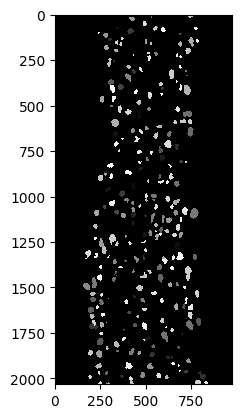

In [4]:
# segmented nuclei mask
stackview.imshow(nuclei_mask[155],axes = True)

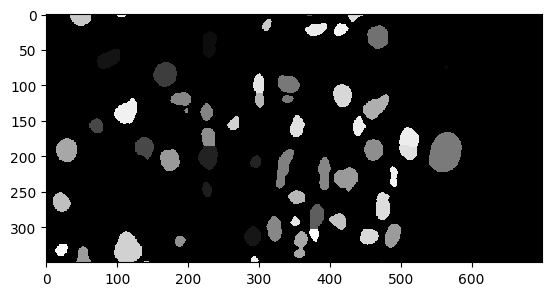

In [6]:
# closer image of nuclei mask
stackview.imshow(nuclei_mask[155, 900:1250,200:900],axes = True)

## 2. Otsus Threshold

In [7]:
threshold_value = threshold_otsu(preprocessed_image[PLANE])
print("extracted threshold value:", threshold_value)

extracted threshold value: 2170.5012


In [8]:
# Create a binary image using the threshold
binary_otsu = preprocessed_image[PLANE] > threshold_value

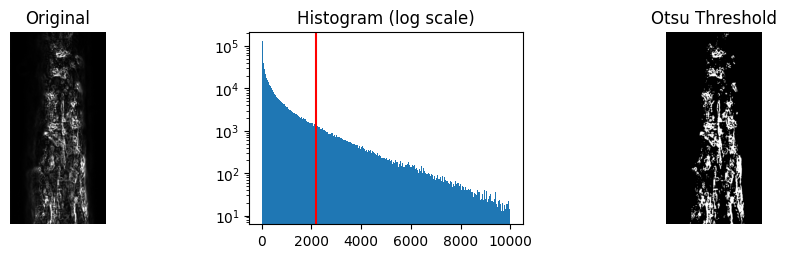

In [9]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[PLANE], cmap=plt.cm.gray, vmax=disp_vmax(preprocessed_image[PLANE]))
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[PLANE].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(threshold_value, color='r')
# Display the thresholded image
ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title('Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

/home/rck292/cardiac_env/lib/python3.11/site-packages/stackview/_imshow.py:54: UserWarning: The parameter cmap is deprecated, use colormap instead.
  warnings.warn("The parameter cmap is deprecated, use colormap instead.")


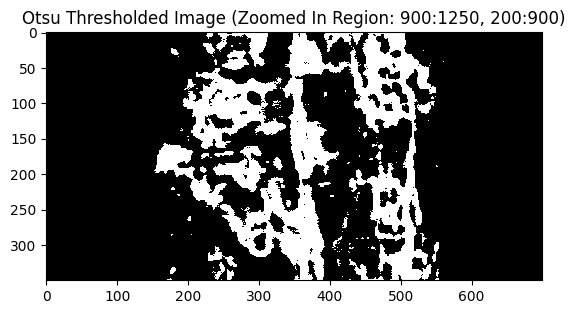

In [10]:
stackview.imshow(binary_otsu[900:1250,200:900], cmap=plt.cm.gray, title='Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 3. Multi-Otsu Threshold

In [11]:
# using bimodal histogram from scikit-image to find the threshold value
thresholds = threshold_multiotsu(preprocessed_image[PLANE], classes=3)
print("extracted threshold values:", thresholds)

extracted threshold values: [1302.3009 4254.1826]


In [12]:
binary_multiotsu = preprocessed_image[PLANE] > thresholds[1]

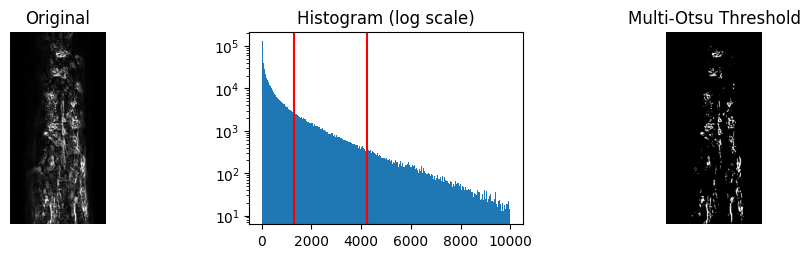

In [13]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[PLANE], cmap=plt.cm.gray, vmax=disp_vmax(preprocessed_image[PLANE]))
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[PLANE].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(thresholds[0], color='r')
ax[1].axvline(thresholds[1], color='r')
# Display the thresholded image
ax[2].imshow(binary_multiotsu, cmap=plt.cm.gray)
ax[2].set_title('Multi-Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

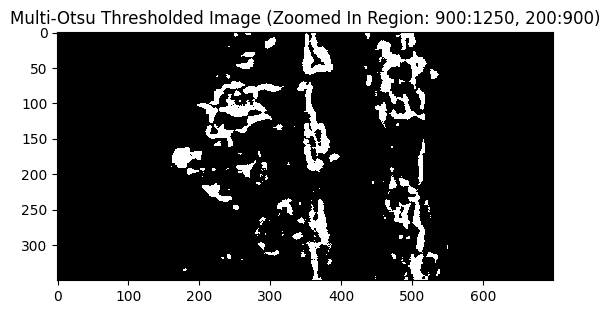

In [14]:
stackview.imshow(binary_multiotsu[900:1250,200:900], cmap=plt.cm.gray, title='Multi-Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 4. Sauvola Threshold

Plaques with min distance 2 detected: 8
Plaques with min distance 2 detected: 86
Plaques with min distance 2 detected: 142
Plaques with min distance 2 detected: 221


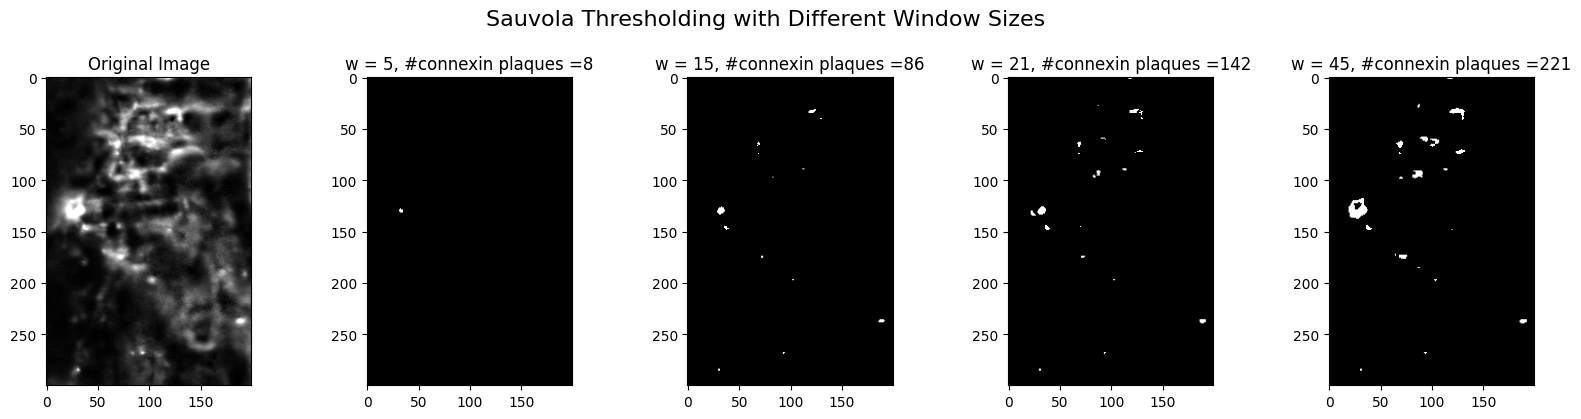

In [15]:
# set some parameters 
min_distance = 2 # connexin size / 2
k_value = 0.15


# Normalize preprocessed image to float [0, 1]
# k the bigger more selective and less foreground [0.2,0.5]
# window size should be 2-3 x diameter of connexin 
# r is 0.5 for image [0,1]
img_float = img_as_float(rescale_intensity(preprocessed_image[PLANE], out_range=(0, 1)))

# Apply adapted Sauvola — no inversion needed
thresh, binary = adapted_sauvola_threshold(img_float, window_size=31, k = k_value , r=0.5)

# stackview.imshow(binary)

thresh, binary_5 = adapted_sauvola_threshold(img_float, window_size=5, k = k_value , r=0.5)
thresh, binary_15 = adapted_sauvola_threshold(img_float, window_size=15, k = k_value , r=0.5)
thresh, binary_21 = adapted_sauvola_threshold(img_float, window_size=21, k = k_value , r=0.5)
thresh, binary_45 = adapted_sauvola_threshold(img_float, window_size=45, k = k_value , r=0.5)

# compute the number of plaques for each binary image 
num_regions_5, labeled_array_5 = count_connexin_plaques(binary_5)
num_regions_15, labeled_array_15 = count_connexin_plaques(binary_15)
num_regions_21, labeled_array_21 = count_connexin_plaques(binary_21)
num_regions_45, labeled_array_45 = count_connexin_plaques(binary_45)

# compute the number of plaques for each binary image -> this counts 2 peaks that are closer than min_distance as one plaque
coordinates_5, n_plaques_5 = count_connexin_plaques_within_plaque(img_float, binary_5, min_distance=min_distance)
coordinates_15, n_plaques_15 = count_connexin_plaques_within_plaque(img_float, binary_15, min_distance=min_distance)
coordinates_25, n_plaques_25 = count_connexin_plaques_within_plaque(img_float, binary_21, min_distance=min_distance)
coordinates_45, n_plaques_45 = count_connexin_plaques_within_plaque(img_float, binary_45, min_distance=min_distance)

#make a subplot with different window sizes 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# set a title for the entire figure with a distance from the top of the figure
fig.suptitle('Sauvola Thresholding with Different Window Sizes', fontsize=16, y=1.05)
axes[0].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
axes[0].set_title('Original Image')
axes[1].imshow(binary_5[950:1250, 350:550], cmap='gray')
axes[1].set_title(f'w = 5, #connexin plaques ={len(coordinates_5)}')
axes[2].imshow(binary_15[950:1250, 350:550], cmap='gray')
axes[2].set_title(f'w = 15, #connexin plaques ={len(coordinates_15)}')
axes[3].imshow(binary_21[950:1250, 350:550], cmap='gray')
axes[3].set_title(f'w = 21, #connexin plaques ={len(coordinates_25)}')
axes[4].imshow(binary_45[950:1250, 350:550], cmap='gray')
axes[4].set_title(f'w = 45, #connexin plaques ={len(coordinates_45)}')
plt.show()

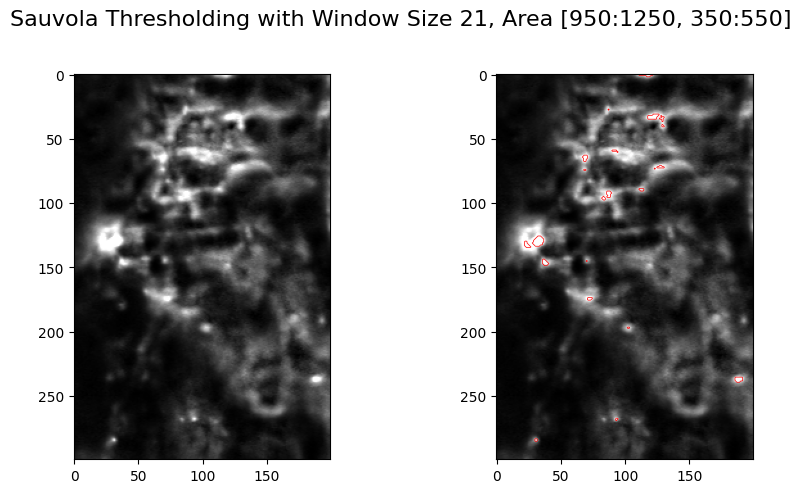

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(10, 5))
fig.suptitle('Sauvola Thresholding with Window Size 21, Area [950:1250, 350:550]', fontsize=16, y=1.01)
ax[0].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[1].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
ax[1].contour( binary_21[950:1250, 350:550], [0.5], linewidths=0.5, colors='r')
plt.show()

## 4. Compare Methods

In [ ]:
mask_areas = io.imread(BASE_DIR / 'data/manual_annotations/small_deconvolved_3d_plane_160_labels.tif')
# match the left cut (3) applied in preprocessing so the annotation stays aligned
mask_areas = mask_areas[:, 3:]

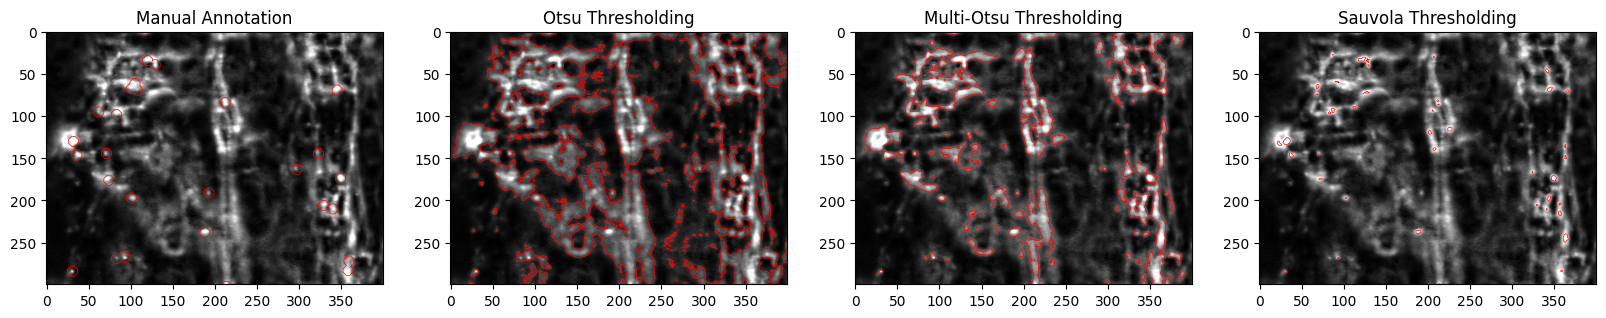

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,4, figsize=(20, 5))
# ax[0].imshow(img_float[950:1250, 350:550], cmap='gray')
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[0].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[0].contour(mask_areas[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[0].set_title('Manual Annotation')
ax[1].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[1].contour(binary_otsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[1].set_title('Otsu Thresholding')
ax[2].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[2].contour( binary_multiotsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[2].set_title('Multi-Otsu Thresholding')
ax[3].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[3].contour( binary_21[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[3].set_title('Sauvola Thresholding')
plt.show()

## 5. Apply Sauvola on 3D image

In [ ]:
# apply the best sauvola thresholding to the entire image
# (2D per-plane threshold, but GLOBAL normalization now - see savola_3D_image in src/threshold.py)
binary_sauvola_raw = savola_3D_image(preprocessed_image, window_size=(21, 21), k=0.15, r=0.5, threeD=False)

# drop noise specks: remove 3D-connected regions below MIN_PLAQUE_VOXELS voxels
# (isolated 1-2 voxel foreground from thresholding, mostly in deep low-signal planes). Tune if needed.
# keep the pre-filter mask (binary_sauvola_raw) so the size plot can report how many plaques were removed.
MIN_PLAQUE_VOXELS = 3
binary_sauvola_img = remove_small_objects(binary_sauvola_raw, min_size=MIN_PLAQUE_VOXELS)
# binary_sauvola_img = sauvola_3d_parallel(
#     preprocessed_image,
#     window_size=(9, 21, 21),
#     k=0.15,
#     r=0.5,
#     chunk_shape=(64, 512, 512),
# )# gave weird results in 3D because of the 3D window; 2D per-plane with global norm is used instead


In [6]:
# save the binary_sauvola_img for later use
io.imsave(
    BASE_DIR / 'data/segmented/binary_sauvola2d_w21_k0_15.tiff',
    img_as_ubyte(binary_sauvola_img)
)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/binary_sauvola2d_w21_k0_15.tiff is a low contrast image
  return func(*args, **kwargs)


In [10]:
count_connexin_plaques(binary_sauvola_img[150])

(np.int32(1),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2033, 976), dtype=int32))

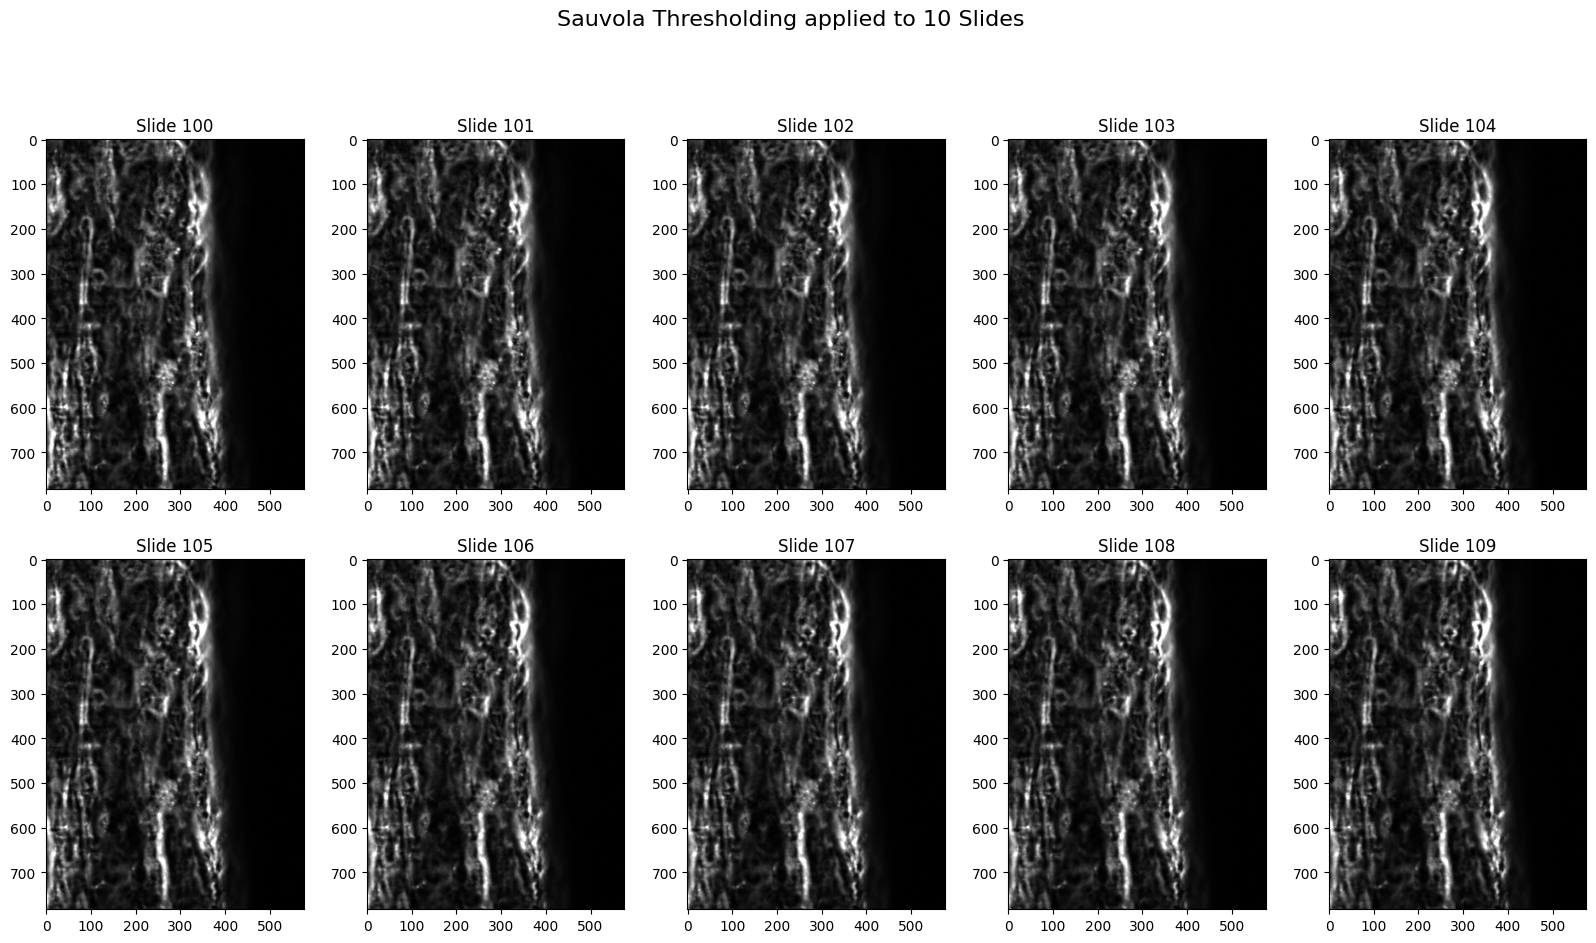

In [11]:
# plot 10 slides with segmented connexin next to each other [950:1250, 350:550]
fig, ax = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Sauvola Thresholding applied to 10 Slides', fontsize=16, y=1.01)
for i in range(10):
    ax[i//5, i%5].imshow(preprocessed_image[100+i][1250:, 400:], cmap='gray', vmax=disp_vmax(preprocessed_image[100+i][1250:, 400:]))
    ax[i//5, i%5].contour(binary_sauvola_img[100+i][1250:, 400:], [0.5], linewidths=0.5, colors='r')
    ax[i//5, i%5].set_title(f'Slide {100+i}')

plt.show()

### Analysis

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_component_counts_per_plane(binary_sauvola_img):
    """
    Count 2D connected components per plane and plot across all planes to check for
    depth trends (e.g. signal loss in deeper planes).

    NOTE: these are per-plane 2D components (cross-sections), not unique 3D plaques —
    a plaque spanning several planes is counted once on each plane. Use the 3D labeling
    in the localization notebook for the true plaque count.
    """
    n_planes = binary_sauvola_img.shape[0]
    counts = np.zeros(n_planes, dtype=int)

    for plane_idx in range(n_planes):
        counts[plane_idx] = count_connexin_plaques(binary_sauvola_img[plane_idx])[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(n_planes), counts, width=1.0, color='steelblue', edgecolor='none')
    ax.set_xlabel('Plane index (z)')
    ax.set_ylabel('Connected components per plane (2D)')
    ax.set_title('Connexin connected components per plane (2D cross-sections)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return counts

In [13]:
binary_sauvola_img.shape

(441, 2033, 976)

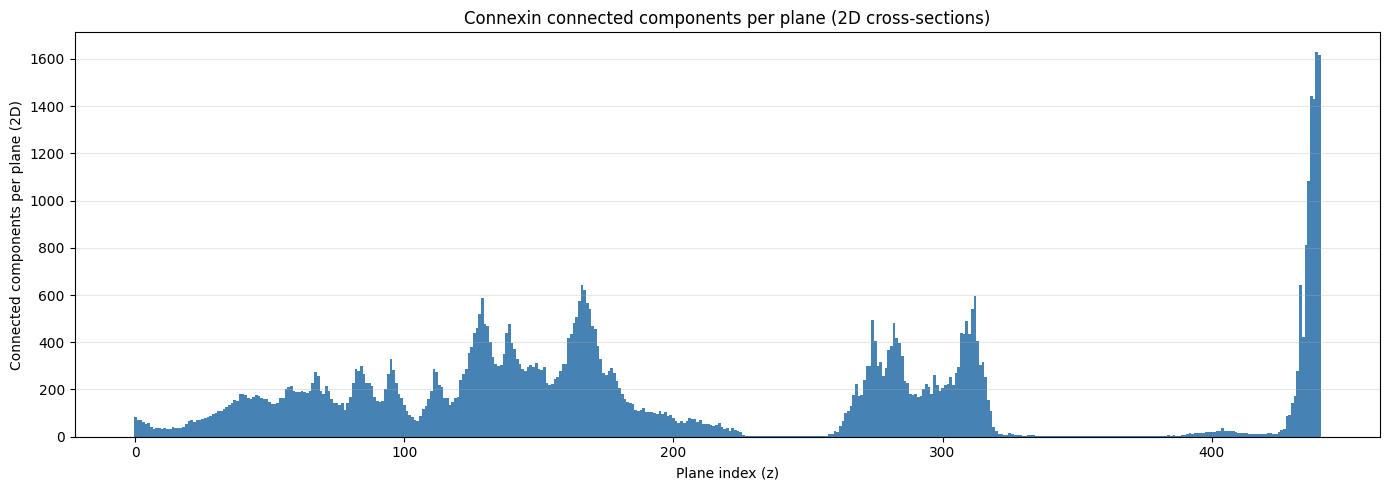

In [24]:
counts = plot_component_counts_per_plane(binary_sauvola_img)

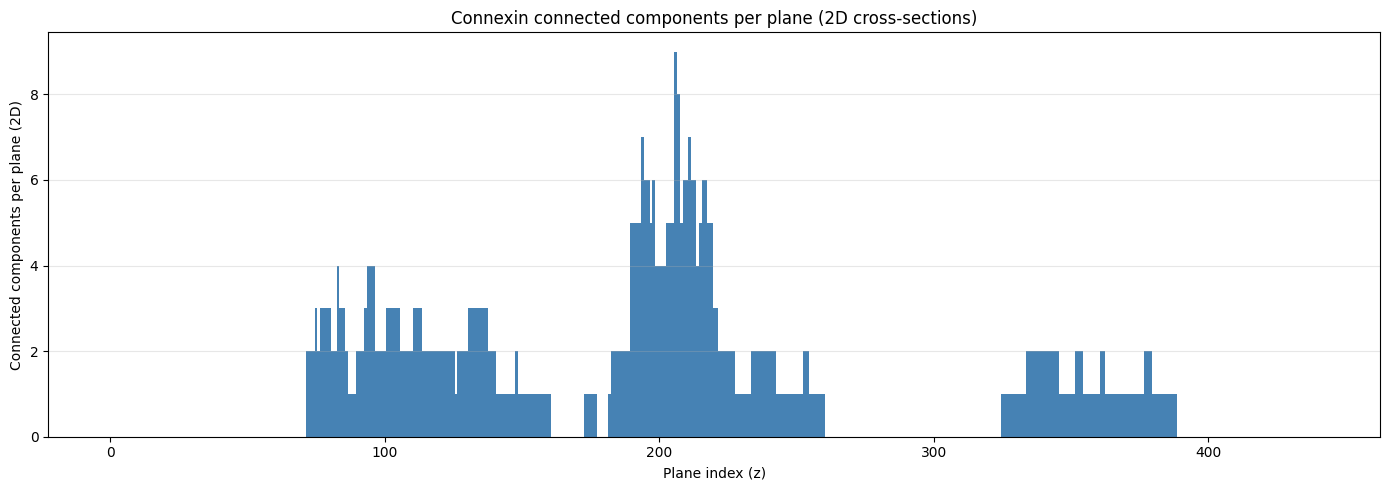

In [14]:
counts = plot_component_counts_per_plane(binary_sauvola_img)

### Plaque size distribution

Size of every segmented connexin plaque (3D connected component) in the final mask, with the min / mean / max and how many plaques the `MIN_PLAQUE_VOXELS` noise filter removed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label

VOXEL_VOLUME_UM3 = 0.766 * 0.325 * 0.325   # z*y*x spacing, matches 3_localization

# plaque sizes (voxels per 3D connected component) before and after the size filter
sizes_raw = np.bincount(label(binary_sauvola_raw, connectivity=1).ravel())[1:]  # drop background (label 0)
sizes = np.bincount(label(binary_sauvola_img, connectivity=1).ravel())[1:]

total = sizes.size
n_removed = int((sizes_raw < MIN_PLAQUE_VOXELS).sum())   # plaques dropped by remove_small_objects
size_min, size_mean, size_max = int(sizes.min()), float(sizes.mean()), int(sizes.max())

print(f"Segmented plaques (3D components): {total}")
print(f"  min  size : {size_min} voxels ({size_min * VOXEL_VOLUME_UM3:.3f} um^3)")
print(f"  mean size : {size_mean:.1f} voxels ({size_mean * VOXEL_VOLUME_UM3:.3f} um^3)")
print(f"  max  size : {size_max} voxels ({size_max * VOXEL_VOLUME_UM3:.3f} um^3)")
print(f"  removed by MIN_PLAQUE_VOXELS={MIN_PLAQUE_VOXELS}: {n_removed} plaques "
      f"({n_removed / (total + n_removed):.1%} of {total + n_removed} before filtering)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sizes, bins=np.logspace(0, np.log10(size_max), 60),
        color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xscale('log'); ax.set_yscale('log')
ax.axvline(MIN_PLAQUE_VOXELS, color='crimson', ls='--', lw=1.3,
           label=f'MIN_PLAQUE_VOXELS = {MIN_PLAQUE_VOXELS} ({n_removed} removed)')
ax.axvline(size_mean, color='darkorange', ls='-', lw=1.3, label=f'mean = {size_mean:.1f} vox')
ax.axvline(size_max, color='green', ls=':', lw=1.3, label=f'max = {size_max} vox')
ax.set_xlabel('Plaque size (voxels, log scale)')
ax.set_ylabel('Number of plaques (log scale)')
ax.set_title(f'Segmented connexin plaque size distribution '
             f'(total={total}, min={size_min}, mean={size_mean:.1f}, max={size_max} voxels)')
ax.legend()
plt.tight_layout()
plt.show()